# Product Analytics & Experimentation Case Study
### Business Problem & Experiment

> An e-commerce platform is testing whether a re-designed checkout call-to-action (CTA) can improve conversion rates.
The existing checkout CTA is a grey "**Proceed to Checkout**" button while the proposed variant is a high contrast-green "**Buy Now - Free Returns**" CTA.

> **The Business Question:** Does the redesign checkout CTA improve conversion without negatively affecting revenue per session?

> **Experiment Design:**

1.   Control (A):
  *   CTA:	Grey - "Proceed to Checkout"
  *   Users: 5000
  *   Test period: Mar 3 - 30, 2026

2.   Variant (B):
  *   CTA: Green - "Buy Now - Free Returns"
  *   Users: 5000
  *   Test period: Mar 3 - 30, 2026

> Users were randomly assigned to either the control or variant experience.

> **Primary Metrics**
 >  *   Conversion Rate (CVR): proportion of sessions resulting in a purchase.
  > *   Revenue per Session: revenue generated per user session.

> **Secondary Metrics**

> *   Bounce Rate
> *   Add-to-Cart Rate (ATCR)
> *   Pages Viewed
> *   Funnel progression
> *   Time to Conversion

> This analysis evaluates both statistical significance and practical significance to determine whether the observed differences are meaningful for product decision-making.

### Dataset

The analysis uses a simulated e-commerce session-level dataset containing 10,000 users, evenly split between the control and variant groups.

Each row represents a user session and contains information about the user's experiment assignment, demographics, acquisition channel, engagement, cart activity, conversion, and revenue.












### Setup, Import Libraries & Load Dataset

In [1]:
# Connect to drive
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style = 'whitegrid',
    rc = {
        'figure.figsize': (11,5),
        'axes.titlepad': 15
    }
)

from scipy import stats

In [3]:
# Load dataset
df = pd.read_excel('/content/drive/MyDrive/A-B Testing: Checkout Button Design/A-B_Test_v3.xlsx', sheet_name='Raw Data')
df.head()

,user_id,variant,session_date,session_hour,device,channel,country,age_group,user_type,pages_viewed,session_duration_sec,items_in_cart,cart_value_usd,bounced,add_to_cart_click,converted,revenue_usd,time_to_convert_sec
0,B102653,B,2025-03-03,20,Desktop,Organic Search,Ethiopia,45-54,Returning,8,263,3,61.64,0,1,1,58.56,72.0
1,B102865,B,2025-03-13,15,Desktop,Organic Search,Ghana,18-24,Returning,7,193,2,37.26,0,1,1,35.86,64.0
2,C103226,Control,2025-03-19,11,Mobile,Paid Social,Nigeria,35-44,New,1,13,1,10.17,1,0,0,0.00,NaN
3,B100912,B,2025-03-21,8,Tablet,Direct,Nigeria,35-44,New,9,257,3,33.42,0,0,0,0.00,NaN
4,B103237,B,2025-03-28,13,Mobile,Organic Search,Ghana,25-34,Returning,1,15,2,43.90,1,0,0,0.00,NaN


### Data Quality Checks

In [4]:
# Dataset dimensions
print(f"Dataset shape: {df.shape}")

# Check missing values
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Duplicated values
print(f"\nDuplicated records: {df.duplicated().sum()}")

# Experimental allocation
print(f"\nExperiment Allocation:\n{df['variant'].value_counts().sort_index(ascending=False)}")

# Inspecting binary variables
binary_cols = ['bounced', 'add_to_cart_click', 'converted']

print("\nInspecting binary variables:")
for col in binary_cols:
  print(df[col].value_counts().sort_index(), "\n")

# Check whether each user appears once
print("Validating uniqueness of records")
print(f"No. of unique records: {df['user_id'].nunique()}")
print(f"Length of df: {len(df)}\n")

# Checking time_to_convert_sec against converted
result = df.groupby('converted')['time_to_convert_sec'].agg(
    ['count', 'min', 'max']
)
print('Checking time_to_convert_sec against converted')
print(result)
print("\nAll good; converted == 0 don't have time_to_convert_sec aggregations")

Dataset shape: (10000, 18)

Missing Values:
user_id                    0
variant                    0
session_date               0
session_hour               0
device                     0
channel                    0
country                    0
age_group                  0
user_type                  0
pages_viewed               0
session_duration_sec       0
items_in_cart              0
cart_value_usd             0
bounced                    0
add_to_cart_click          0
converted                  0
revenue_usd                0
time_to_convert_sec     7785
dtype: int64

Duplicated records: 0

Experiment Allocation:
variant
Control    5000
B          5000
Name: count, dtype: int64

Inspecting binary variables:
bounced
0    7800
1    2200
Name: count, dtype: int64 

add_to_cart_click
0    6426
1    3574
Name: count, dtype: int64 

converted
0    7785
1    2215
Name: count, dtype: int64 

Validating uniqueness of records
No. of unique records: 10000
Length of df: 10000

Checking time_t

## Exploratory Data Analysis (EDA)

> EDA will shed more light on user behavior across both experiment groups; further it will identify patterns and trends that may influence conversion, bounce rate, and revenue optimization.

> This section examines overall permaformance of both variants, and differences across device, marketing channel, user engagement, cart activity, age groups, and country.





### Overall Performance by Variant

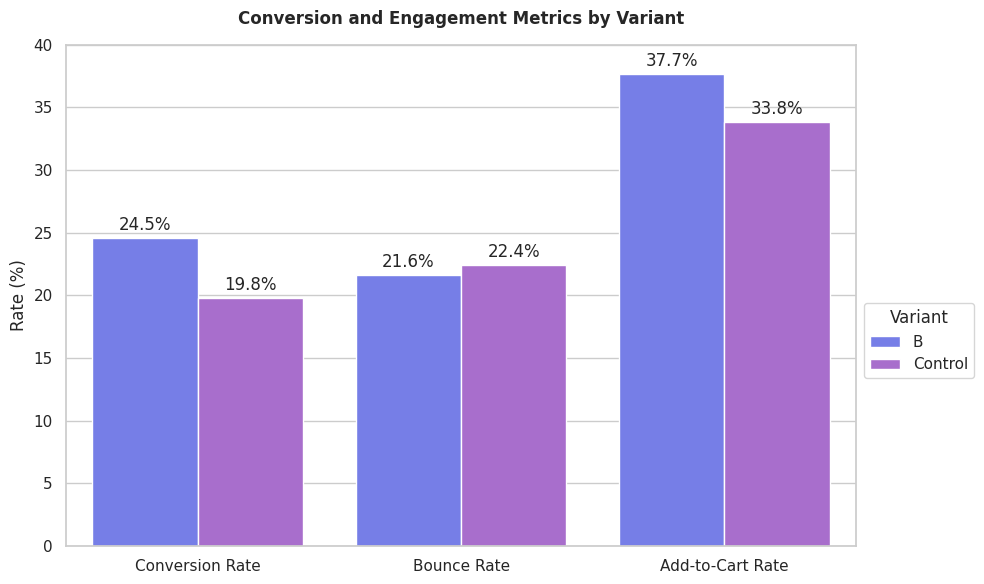

In [10]:
# Overall performance by variant
variant_summary = df.groupby('variant').agg(
    n_users = ('user_id', 'count'),
    conversions = ('converted', 'sum'),
    revenue = ('revenue_usd', 'sum'),
    bounced = ('bounced', 'sum'),
    add_to_cart = ('add_to_cart_click', 'sum'),
    avg_pages_viewed = ('pages_viewed', 'mean')
)

# Calc CVR
variant_summary['conversion_rate'] = (
    variant_summary['conversions'] / variant_summary['n_users']
)

# Calc bounce rate
variant_summary['bounce_rate'] = (
    variant_summary['bounced'] / variant_summary['n_users']
)

# Calc add to cart rate (ATCR)
variant_summary['add_to_cart_rate'] = (
    variant_summary['add_to_cart'] / variant_summary['n_users']
)

# Calc revenue per session
variant_summary['revenue_per_session'] = (
    variant_summary['revenue'] / variant_summary['n_users']
)

# Visual comparison of CVR, bounce rate & add-to-cart rate by product variant
performance_metrics = variant_summary[
    ["conversion_rate", "bounce_rate", "add_to_cart_rate"]
].reset_index()

performance_metrics = performance_metrics.melt(
    id_vars="variant",
    var_name="metric",
    value_name="rate"
)

performance_metrics["rate"] *= 100

performance_metrics["metric"] = performance_metrics["metric"].replace({
    "conversion_rate": "Conversion Rate",
    "bounce_rate": "Bounce Rate",
    "add_to_cart_rate": "Add-to-Cart Rate"
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=performance_metrics,
    x="metric",
    y="rate",
    hue="variant",
    palette={"Control": "#AB5EDC", "B": "#636EFA"}
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Conversion and Engagement Metrics by Variant", fontweight='bold')
plt.xlabel("")
plt.ylabel("Rate (%)")
plt.ylim(0, 40)
plt.legend(title="Variant", bbox_to_anchor=(1.,0.5))
plt.tight_layout()
plt.show()

**Key Insights:**Variant B shows better conversion and engagement across all three metrics.

### Conversion and Bounce Rates by Device

> Does the new checkout design behave differently across devices?



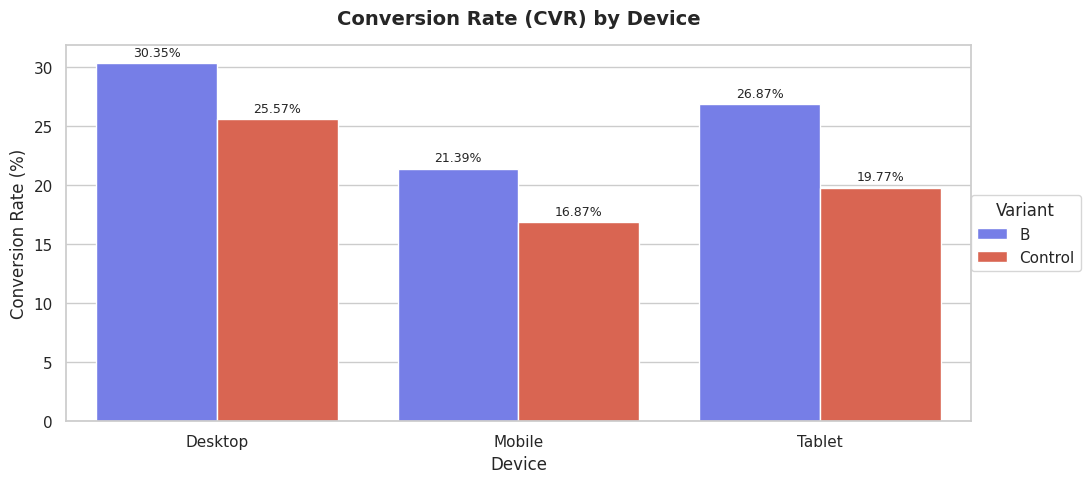

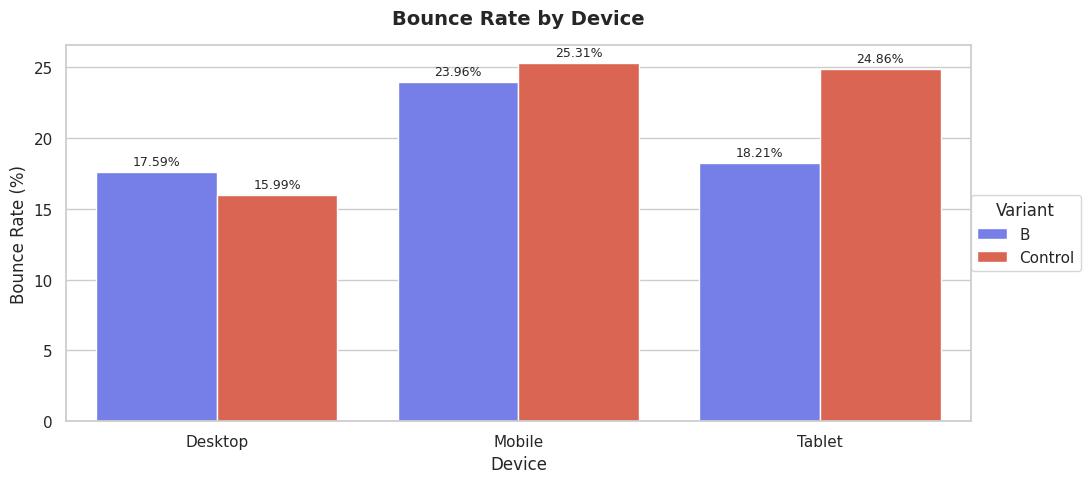

In [13]:
device_summary = df.groupby(['device', 'variant']).agg(
    users = ('user_id', 'count'),
    conversions = ('converted', 'sum'),
    bounced = ('bounced', 'sum')
).reset_index()

# Calc conversion rate (CVR)
device_summary['conversion_rate'] = (
    device_summary['conversions'] / device_summary['users']
)*100

# Calc bounce rate
device_summary['bounce_rate'] = (
    device_summary['bounced'] / device_summary['users']
)*100

# Set color palette
palette = {
    'Control': '#EF553B',
    'B': '#636EFA'
}

# Viz CVR
plt.figure()

ax = sns.barplot(
    data=device_summary,
    x='device',
    y='conversion_rate',
    hue='variant',
    palette=palette
)

plt.title('Conversion Rate (CVR) by Device', fontsize=14, fontweight='bold')
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')

# Add % labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.legend(title='Variant', loc='center right', bbox_to_anchor=(1.13, 0.5))
plt.tight_layout()
plt.show()


# Viz Bounce Rate
plt.figure()

ax = sns.barplot(
    data=device_summary,
    x='device',
    y='bounce_rate',
    hue='variant',
    palette=palette
)

plt.title('Bounce Rate by Device', fontsize=14, fontweight='bold')
plt.xlabel('Device')
plt.ylabel('Bounce Rate (%)')

# Add % labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.legend(title='Variant', loc='center right', bbox_to_anchor=(1.13, 0.5))
plt.tight_layout()
plt.show()

**Key Insights:** The redesign improves conversion across all devices, with the strongest gains seen in Desktop and Tablets; Mobile devces shows mixed results with high conversion rates but also the highest bounce rates.

### Conversion Rate and Bounce Rate by Marketing Channel

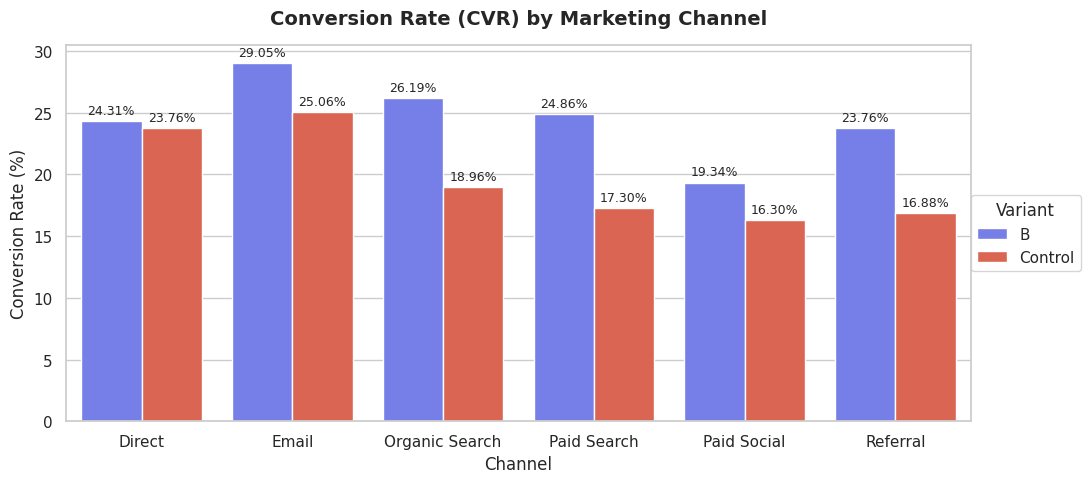

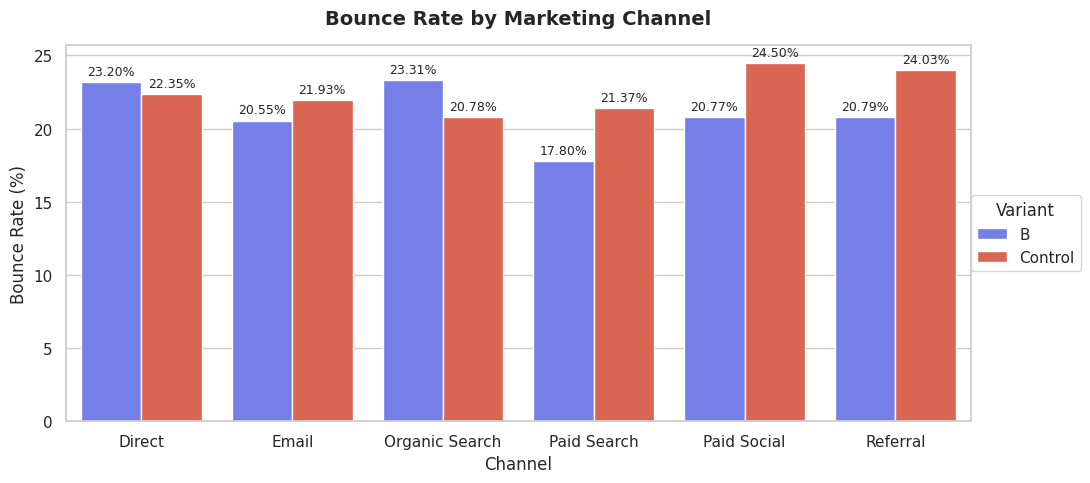

In [16]:
channel_summary = df.groupby(['channel', 'variant']).agg(
    users = ('user_id', 'count'),
    conversions = ('converted', 'sum'),
    bounced = ('bounced', 'sum')
).reset_index()

# Calc conversion rate (CVR)
channel_summary['conversion_rate'] = (
    channel_summary['conversions'] / channel_summary['users']
)*100

# Calc bounce rate
channel_summary['bounce_rate'] = (
    channel_summary['bounced'] / channel_summary['users']
)*100

# Viz CVR
plt.figure()

ax = sns.barplot(
    data=channel_summary,
    x='channel',
    y='conversion_rate',
    hue='variant',
    palette=palette
)

plt.title('Conversion Rate (CVR) by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Conversion Rate (%)')

# Add % labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.legend(title='Variant', loc='center right', bbox_to_anchor=(1.13, 0.5))
plt.tight_layout()
plt.show()


# Viz Bounce Rate
plt.figure()

ax = sns.barplot(
    data=channel_summary,
    x='channel',
    y='bounce_rate',
    hue='variant',
    palette=palette
)

plt.title('Bounce Rate by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Bounce Rate (%)')

# Add % labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.legend(title='Variant', loc='center right', bbox_to_anchor=(1.13, 0.5))
plt.tight_layout()
plt.show()

**Key Insights:** The redesign shows consistent gains in conversion rates across all marketing channels with notable gains in Organic Search, Paid Search, & Referrals.

### Pages Viewed

> Does the redesigned checkout affect user engagement or browsing behavior?



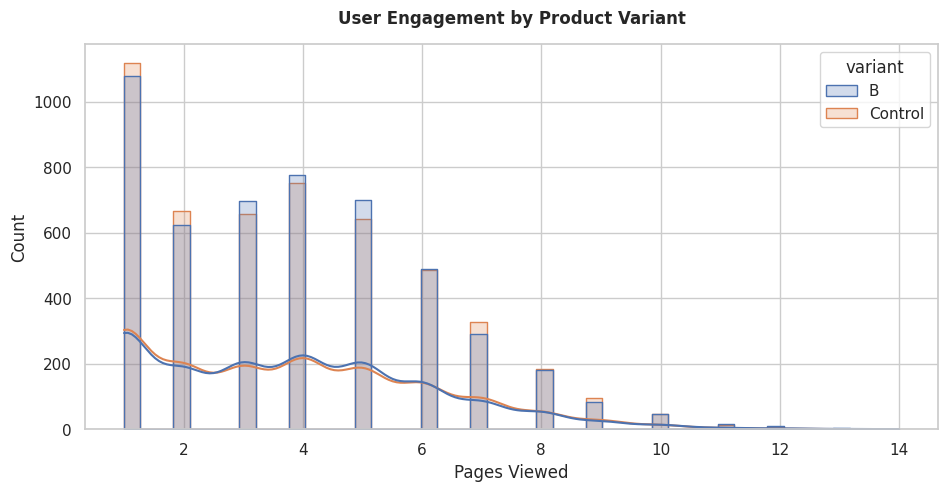

In [18]:
sns.histplot(
    data=df,
    x="pages_viewed",
    hue="variant",
    kde=True,
    element="step"
)

plt.title("User Engagement by Product Variant", fontweight='bold')
plt.xlabel("Pages Viewed")
plt.show()

**Key Insights:** User engagement trends appears to be similar for both variants; majority of users lose interest after the landing page while consistent traffic is observed from page 2 to page 5. Further statistical analysis is required to determine the significance of the observed differences.

### Add-to-cart Rate by Device and Marketing Channel

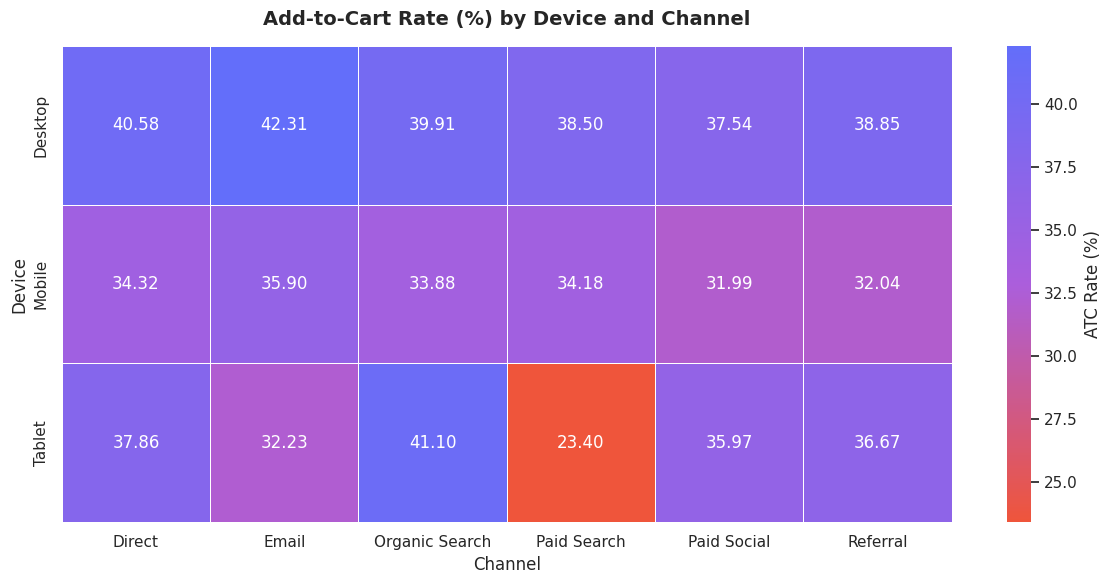

In [19]:
from matplotlib.colors import LinearSegmentedColormap

# ATC Rate (%) by device and channel
atc_rate = (
    df.groupby(['device', 'channel'])['add_to_cart_click']
    .mean()
    .mul(100)
    .round(2)
    .rename('ATC_Rate')
    .reset_index()
)

# HEATMAP VISUALIZATION

# Pivot for heatmap
heatmap_data = atc_rate.pivot(
    index='device',
    columns='channel',
    values='ATC_Rate'
)

# Heatmap
plt.figure(figsize=(12, 6))

# Custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_plotly',
    ['#EF553B', '#AB5EDC', '#636EFA']
)

sns.heatmap(
    heatmap_data,
    annot=True,          # Show labels
    fmt='.2f',
    cmap=custom_cmap,
    linewidths=0.5,
    cbar_kws={'label': 'ATC Rate (%)'}
)

plt.title('Add-to-Cart Rate (%) by Device and Channel',
          fontsize=14, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Device')
plt.tight_layout()

plt.show()

**Key Insights:** Email performs strongly across Desktop and Mobile, while Organic Search is strongest on Tablet; Paid Social and Referral show relatively weaker ATC performance on Mobile; Paid Search performs terribly on tablets.

### Revenue per Session by Country

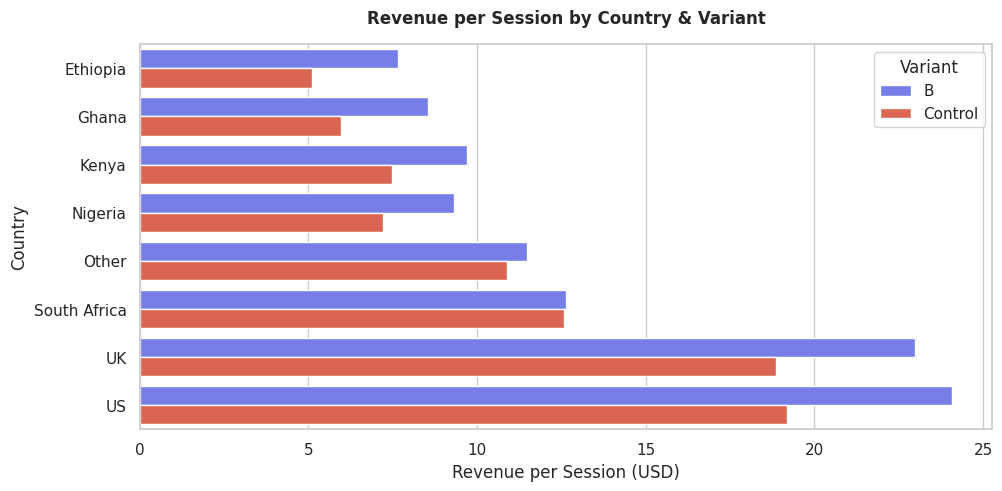

In [22]:
# Country revenue stats
country_rev = df.groupby(['country', 'variant']).agg(
    sessions = ('user_id', 'count'),
    revenue = ('revenue_usd', 'sum')
).reset_index()

# Calc revenue per session
country_rev['rev_per_session'] = (
    country_rev['revenue'] / country_rev['sessions']
)

# Viz
# Custom colors
palette = {
    "Control": "#EF553B",
    "B": "#636EFA"
}

sns.barplot(
    data = country_rev,
    x = 'rev_per_session',
    y = 'country',
    hue = 'variant',
    palette = palette
)

plt.title('Revenue per Session by Country & Variant', fontweight='bold')
plt.xlabel('Revenue per Session (USD)')
plt.ylabel('Country')
plt.legend(title='Variant')
plt.show()

**Key Insights:** Variant B consistently outperformed the Control in revenue per session across all countries except South Africa where the revenue per session was almost similar for both variants. This suggests Variant B has a broadly positive revenue effect but further statistical analysis is required to determine the significance of observed differences.

### Revenue per Session by Age Group

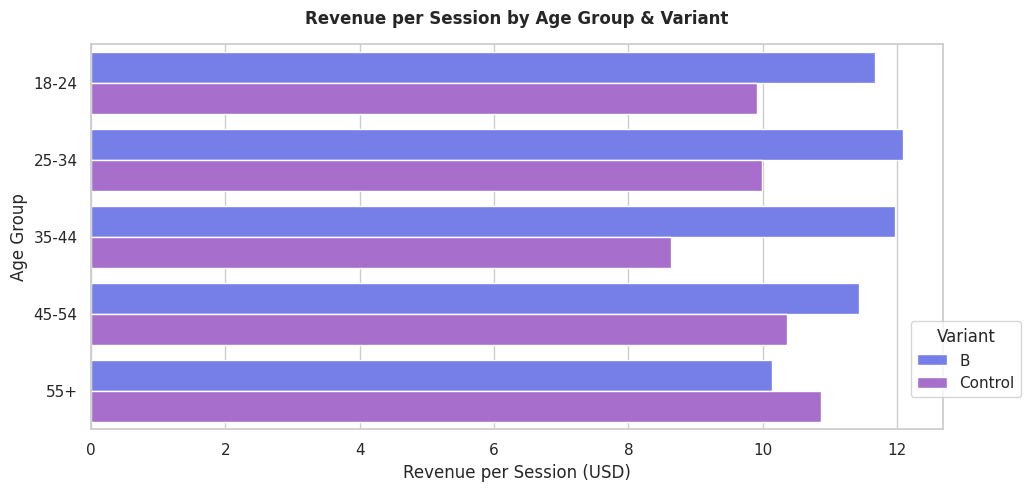

In [25]:
# Revenue by age group stats
revenue_by_age = df.groupby(['age_group', 'variant']).agg(
    sessions = ('user_id', 'count'),
    revenue = ('revenue_usd', 'sum')
).reset_index()

# Calc revenue per session
revenue_by_age['rev_per_session'] = (
    revenue_by_age['revenue'] / revenue_by_age['sessions']
)

# Viz
# Custom colors
palette = {
    "Control": "#AB5EDC",
    "B": "#636EFA"
}
sns.barplot(
    data = revenue_by_age,
    x = 'rev_per_session',
    y = 'age_group',
    hue = 'variant',
    palette = palette
)

plt.title('Revenue per Session by Age Group & Variant', fontweight='bold')
plt.xlabel('Revenue per Session (USD)')
plt.ylabel('Age Group')
plt.legend(
    title='Variant',
    bbox_to_anchor = (1.1, 0.3)
)
plt.show()

**Key Insights:** Variant B generated higher revenue per session across all age groups except 55+, where Control performed slightly better. Overall, Variant B appears to perform particularly well with users aged 25–44.

## Experimentation

> A statistical hypothesis test was used to determine whether the differences between the product variants (Control and Variant B) were statistically significant or occurred due to random chance.

> Statistical significance was evaluated at a significance level of **α = 0.05**; effect size was also evaluated to distinguish practical relevance and statistical significance.




### Conversion Rate (CVR) Significance Test

> A two proportion z-test was used to determine whether the CVR of both product variants were statistically different.

> **Null Hypothesis (H0):** There is no difference in CVR between control and variant B.

> **Alternative Hypothesis:** There is a significant difference in CVR between control and variant B.







In [ ]:
# Function to test difference in CVR between control and variant B
# using a z-test of proportions

def z_test_proportions(df):
    control = df[df["variant"] == "Control"]["converted"]
    variant_b = df[df["variant"] == "B"]["converted"]

    # Sample sizes
    n_c = len(control)
    n_b = len(variant_b)

    # Number of conversions
    x_c = control.sum()
    x_b = variant_b.sum()

    # Conversion rates
    c_cvr = x_c / n_c
    b_cvr = x_b / n_b

    # Pooled proportion
    p_pool = (x_c + x_b) / (n_c + n_b)

    # Standard error
    se = np.sqrt(
        p_pool * (1 - p_pool) *
        (1 / n_c + 1 / n_b)
    )

    # z-statistic
    z = (b_cvr - c_cvr) / se

    # Two-sided p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    print(f"Control CVR: {c_cvr:.2%}")
    print(f"Variant B CVR: {b_cvr:.2%}")
    print(f"Absolute difference: {(b_cvr - c_cvr):.2%}")
    print(f"z-statistic: {z:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("\nResult: Reject H₀.")
        print("The difference in conversion rates is statistically significant.")
    else:
        print("\nResult: Fail to reject H₀.")
        print("There is insufficient evidence of a statistically significant difference.")

    return z, p_value

In [ ]:
# Run the function
z, p_value = z_test_proportions(df)


Control CVR: 19.7600%
Variant B CVR: 24.5400%
Absolute difference: 4.7800%
z-statistic: 5.7555
p-value: 0.000000

Result: Reject H₀.
The difference in conversion rates is statistically significant.


**Variant B increased conversion rate from 19.76% to 24.54%. The z-test confirms the difference is statistically significant (p < 0.001); there is strong evidence that  the checkout redesign improves conversion.**


### Revenue per Session Significance Test (Mann Whitney U Test).

> Revenue per session was compared between control and B variant using Mann-Whitney U test; this test is ideal for this scenerio because revenue data can be skewed and non-normal.

> **Null Hypothesis:** The revenue distributions between Control and B variant are equal.

> **Alternative Hypothesis**: Variant B generates higher revenue per session than control.

> A one-tailed two test was used with a **significance level of 0.05.**









In [ ]:
# Filter the control and B revenue arrays
c_rev = df.query("variant == 'Control'")['revenue_usd']
b_rev = df.query("variant == 'B'")['revenue_usd']

# Descriptive comparison between the variants
c_rps = c_rev.mean()
b_rps = b_rev.mean()

print(f"Control Revenue/Session: ${c_rps:.2f}")
print(f"Variant B Revenue/Session: ${b_rps:.2f}")
print(f"Difference: ${b_rps - c_rps:.2f}")
print(f"Relative Difference: {(b_rps / c_rps - 1):.2%}")

# Run the test of significance
stat, p_val = stats.mannwhitneyu(
    b_rev,
    c_rev,
    alternative='greater' # one-tailed >> B is greater than control
)

# Print results
print(f"\nU Statistic: {stat:,.0f}")
print(f"p-value: {p_val:.4f}\n")

# Deductions
if p_val < 0.05:
  print("Reject Null Hypothesis: There is evidence to suggests that Variant B generates higher revenue per session than control.")
else:
  print("Fail to reject Null Hypothesis: The revenue distributions between Control and B variant are equal.")

Control Revenue/Session: $9.72
Variant B Revenue/Session: $11.75
Difference: $2.04
Relative Difference: 20.96%

U Statistic: 13,088,261
p-value: 0.0000

Reject Null Hypothesis: There is evidence to suggests that Variant B generates higher revenue per session than control.


**Variant B increased revenue per session from $9.72 to $11.75, a $2.04 (+20.96%) uplift. The Mann–Whitney U test indicates the difference is statistically significant (p < 0.001); there is evidence that the redesigned checkout results in higher revenue per session.**


### Effect size & Average Order Value (AOV)

In [ ]:
# Calculate effect size: Does the significant effect detected really matter?

# Sample sizes
n1 = len(b_rev)
n2 = len(c_rev)
N = n1 + n2

# Mean U
mean_U = n1 * n2 / 2

# Standard deviation of U
sd_U = np.sqrt(n1 * n2 * (N + 1) / 12)

# Z statistic
z = (stat - mean_U) / sd_U

# Effect size
r = z / np.sqrt(N)

#print(f"Z statistic: {z:.4f}")
print(f"Effect size (r): {r:.4f}")


# Revenue among converted users only
df_conv = df[df["converted"] == 1]

aov = (
    df_conv.groupby("variant")["revenue_usd"]
    .mean()
)

print(f"\nControl AOV: ${aov['Control']:.2f}")
print(f"Variant B AOV: ${aov['B']:.2f}")

# Calc the diff
aov_diff = aov["B"] - aov["Control"]
aov_pct_diff = (aov["B"] / aov["Control"] - 1) * 100

print(f"\nAOV difference: ${aov_diff:.2f}")
print(f"AOV relative difference: {aov_pct_diff:.2f}%")

Effect size (r): 0.0408

Control AOV: $49.17
Variant B AOV: $47.89

AOV difference: $-1.28
AOV relative difference: -2.60%


**Variant B generated higher revenue per session, but the average order value was slightly lower ($47.89 vs $49.17), a 2.60% decrease. The small effect size (r = 0.0408) indicates the difference in revenue distributions is weak, suggesting Variant B’s revenue gains are driven more by increased conversions rather than by larger individual orders.**


### Funnel Analysis

> This funnel analysis investigates whether the redesigned checkout button had an effect on user progression from engagement to purchase. Three stages - session, add to cart, & conversion - are compared between Control and B variants to determine whether users are gained or lost during the engagement journey.



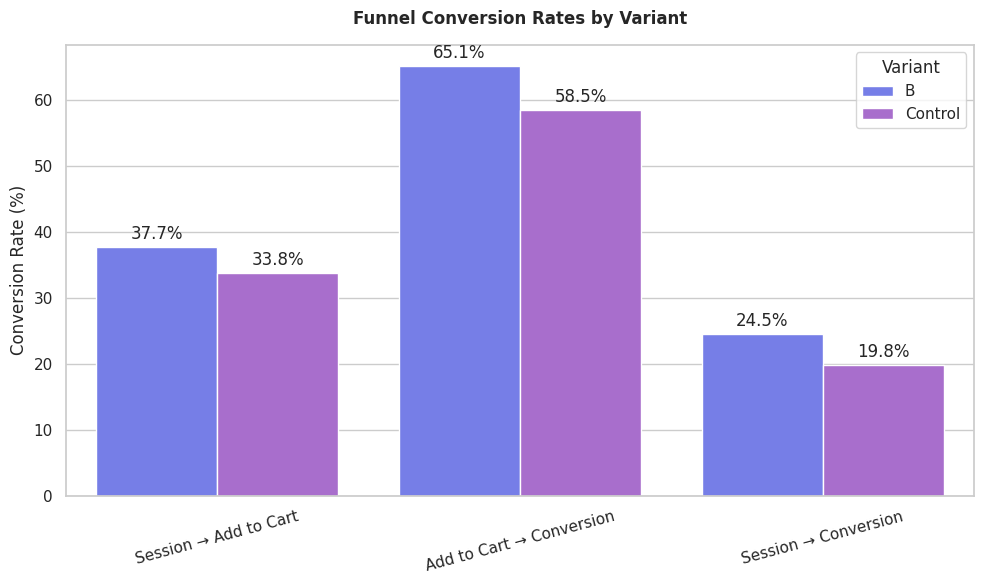

In [ ]:
# Create the funnel
funnel = df.groupby("variant").agg(
    sessions=("user_id", "count"),
    add_to_cart=("add_to_cart_click", "sum"),
    conversions=("converted", "sum")
).reset_index()

funnel["session_to_cart"] = funnel["add_to_cart"] / funnel["sessions"]
funnel["cart_to_conversion"] = funnel["conversions"] / funnel["add_to_cart"]
funnel["session_to_conversion"] = funnel["conversions"] / funnel["sessions"]

# Viz the funnel
funnel_rates = funnel.melt(
    id_vars="variant",
    value_vars=[
        "session_to_cart",
        "cart_to_conversion",
        "session_to_conversion"
    ],
    var_name="stage",
    value_name="rate"
)

funnel_rates["rate"] *= 100

funnel_rates["stage"] = funnel_rates["stage"].replace({
    "session_to_cart": "Session → Add to Cart",
    "cart_to_conversion": "Add to Cart → Conversion",
    "session_to_conversion": "Session → Conversion"
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=funnel_rates,
    x="stage",
    y="rate",
    hue="variant",
    palette={"Control": "#AB5EDC", "B": "#636EFA"}
)

# Add % labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Funnel Conversion Rates by Variant", fontweight='bold')
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=15)
plt.legend(title="Variant")
plt.tight_layout()
plt.show()

**Variant B improved performance across all stages of the funnel; the overall session-to-conversion improved with 4.8 percentage points. This indicates that the redesigned checkout button increased progression across all stages of the funnel. Considering the funnel analysis alongside the revenue analysis, we can conclude that variant B converts more users, but does not generate more revenue per user.**

